In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, ClassifierMixin, clone
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
def load_data():

    folder = "../Preprocessing-FeatureExtraction/cleaned-data/"
    csv_files = glob.glob(os.path.join(folder, "*.csv"))
    
    dfs = []
    for file in csv_files:
        df = pd.read_csv(file)
        df['state'] = os.path.splitext(os.path.basename(file))[0]
        dfs.append(df)
    
    data = pd.concat(dfs, ignore_index=True)
    df = data.dropna()    
    print(f"Loaded {len(df)} reviews from {len(dfs)} states.")
    return df

In [3]:
def plot_confusion_matrix(y_true, y_pred, title, labels=[0,1,2], save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels,
                yticklabels=labels)
    plt.title(title, fontsize=16)
    plt.ylabel('True Star Rating', fontsize=12)
    plt.xlabel('Predicted Star Rating', fontsize=12)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
# class LayeredStarClassifier:
#     """
#     Two-layer hierarchical classifier:
#     Layer 1: Split reviews into low/mid (1-3) vs mid/high (3-5)
#     Layer 2A: For low/mid group, predict 1-3
#     Layer 2B: For mid/high group, predict 3-5
#     """

#     def __init__(self, max_features=10000, ngram_range=(1, 2)):
#         # Layer 1: Coarse group classifier (1–3 vs 3–5)
#         self.group_classifier = LogisticRegression(max_iter=1000, random_state=42)

#         # Layer 2A: Fine classifier for 1–3
#         self.lowmid_classifier = LogisticRegression(max_iter=1000, random_state=42)

#         # Layer 2B: Fine classifier for 3–5
#         self.midhigh_classifier = LogisticRegression(max_iter=1000, random_state=42)

#         # Vectorizers
#         self.group_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
#         self.lowmid_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
#         self.midhigh_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

#     def fit(self, X_train, y_train):
#         if not isinstance(X_train, pd.Series):
#             X_train = pd.Series(X_train)
#         if not isinstance(y_train, pd.Series):
#             y_train = pd.Series(y_train)

#         print("\n=== Training Layer 1: Group Classifier (1-3 vs 3-5) ===")
#         group_labels = y_train.apply(lambda x: 0 if x <= 3 else 1)
#         X_train_group = self.group_vectorizer.fit_transform(X_train)
#         self.group_classifier.fit(X_train_group, group_labels)
#         print("Layer 1 training accuracy:",
#               accuracy_score(group_labels, self.group_classifier.predict(X_train_group)))

#         # -----------------------
#         # Layer 2A: 1–3 classifier
#         # -----------------------
#         lowmid_mask = y_train <= 3
#         X_train_lowmid = X_train[lowmid_mask]
#         y_train_lowmid = y_train[lowmid_mask]

#         print("\n=== Training Layer 2A: Low/Mid Classifier (1,2,3) ===")
#         X_train_lowmid_tfidf = self.lowmid_vectorizer.fit_transform(X_train_lowmid)
#         self.lowmid_classifier.fit(X_train_lowmid_tfidf, y_train_lowmid)
#         print("Layer 2A training accuracy:",
#               accuracy_score(y_train_lowmid,
#                              self.lowmid_classifier.predict(X_train_lowmid_tfidf)))

#         # -----------------------
#         # Layer 2B: 3–5 classifier
#         # -----------------------
#         midhigh_mask = y_train >= 3
#         X_train_midhigh = X_train[midhigh_mask]
#         y_train_midhigh = y_train[midhigh_mask]

#         print("\n=== Training Layer 2B: Mid/High Classifier (3,4,5) ===")
#         X_train_midhigh_tfidf = self.midhigh_vectorizer.fit_transform(X_train_midhigh)
#         self.midhigh_classifier.fit(X_train_midhigh_tfidf, y_train_midhigh)
#         print("Layer 2B training accuracy:",
#               accuracy_score(y_train_midhigh,
#                              self.midhigh_classifier.predict(X_train_midhigh_tfidf)))

#         print("\n=== Training Complete ===")

#     def predict(self, X_test):
#         if not isinstance(X_test, pd.Series):
#             X_test = pd.Series(X_test)

#         n = len(X_test)
#         predictions = np.zeros(n, dtype=int)

#         # Layer 1 predictions
#         X_test_group = self.group_vectorizer.transform(X_test)
#         group_pred = self.group_classifier.predict(X_test_group)

#         # Low/Mid group
#         lowmid_mask = group_pred == 0
#         if lowmid_mask.sum() > 0:
#             X_lowmid = X_test[lowmid_mask]
#             X_lowmid_tfidf = self.lowmid_vectorizer.transform(X_lowmid)
#             predictions[lowmid_mask] = self.lowmid_classifier.predict(X_lowmid_tfidf)

#         # Mid/High group
#         midhigh_mask = group_pred == 1
#         if midhigh_mask.sum() > 0:
#             X_midhigh = X_test[midhigh_mask]
#             X_midhigh_tfidf = self.midhigh_vectorizer.transform(X_midhigh)
#             predictions[midhigh_mask] = self.midhigh_classifier.predict(X_midhigh_tfidf)

#         return predictions

In [5]:
# import numpy as np
# import pandas as pd
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

# class LayeredStarClassifier:
#     """
#     Two-layer hierarchical classifier with overlap on 3-star reviews:
#     Layer 1: Classifies reviews as low/mid (1-3) vs mid/high (3-5),
#              with 3-star samples duplicated into both groups.
#     Layer 2A: Predicts fine-grained rating for 1-3.
#     Layer 2B: Predicts fine-grained rating for 3-5.
#     Prediction uses soft routing based on Layer 1 probabilities.
#     """

#     def __init__(self, max_features=10000, ngram_range=(1, 2)):
#         # Classifiers
#         self.group_classifier = LogisticRegression(max_iter=1000, random_state=42)
#         self.lowmid_classifier = LogisticRegression(max_iter=1000, random_state=42)
#         self.midhigh_classifier = LogisticRegression(max_iter=1000, random_state=42)

#         # Vectorizers
#         self.group_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
#         self.lowmid_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
#         self.midhigh_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

#     def fit(self, X_train, y_train):
#         if not isinstance(X_train, pd.Series):
#             X_train = pd.Series(X_train)
#         if not isinstance(y_train, pd.Series):
#             y_train = pd.Series(y_train)

#         # -----------------------
#         # LAYER 1: 1–3 vs 3–5 (duplicate 3-star samples)
#         # -----------------------
#         print("\n=== Training Layer 1: Group Classifier (1-3 vs 3-5, with duplicated 3s) ===")

#         low_mask = y_train <= 3
#         high_mask = y_train >= 3

#         X_low = X_train[low_mask]
#         y_low = pd.Series(0, index=X_low.index)
#         X_high = X_train[high_mask]
#         y_high = pd.Series(1, index=X_high.index)

#         # Duplicate 3-stars in both
#         X_group = pd.concat([X_low, X_high])
#         y_group = pd.concat([y_low, y_high])
#         X_group_tfidf = self.group_vectorizer.fit_transform(X_group)
#         self.group_classifier.fit(X_group_tfidf, y_group)

        
#         print("Layer 1 training accuracy:",
#               accuracy_score(y_group, self.group_classifier.predict(X_group_tfidf)))

#         # -----------------------
#         # LAYER 2A: 1–3 (duplicate 3s)
#         # -----------------------
#         print("\n=== Training Layer 2A: Low/Mid Classifier (1,2,3) ===")
#         lowmid_mask = y_train <= 3
#         X_lowmid = X_train[lowmid_mask]
#         y_lowmid = y_train[lowmid_mask]

#         overlap_mask = y_train == 3
#         X_overlap = X_train[overlap_mask]
#         y_overlap = y_train[overlap_mask]

#         # duplicate 3-star reviews
#         X_lowmid = pd.concat([X_lowmid, X_overlap])
#         y_lowmid = pd.concat([y_lowmid, y_overlap])

#         X_lowmid_tfidf = self.lowmid_vectorizer.fit_transform(X_lowmid)
#         self.lowmid_classifier.fit(X_lowmid_tfidf, y_lowmid)
#         print("Layer 2A training accuracy:",
#               accuracy_score(y_lowmid, self.lowmid_classifier.predict(X_lowmid_tfidf)))

#         # -----------------------
#         # LAYER 2B: 3–5 (duplicate 3s)
#         # -----------------------
#         print("\n=== Training Layer 2B: Mid/High Classifier (3,4,5) ===")
#         midhigh_mask = y_train >= 3
#         X_midhigh = X_train[midhigh_mask]
#         y_midhigh = y_train[midhigh_mask]

#         X_midhigh = pd.concat([X_midhigh, X_overlap])
#         y_midhigh = pd.concat([y_midhigh, y_overlap])

#         X_midhigh_tfidf = self.midhigh_vectorizer.fit_transform(X_midhigh)
#         self.midhigh_classifier.fit(X_midhigh_tfidf, y_midhigh)
#         print("Layer 2B training accuracy:",
#               accuracy_score(y_midhigh, self.midhigh_classifier.predict(X_midhigh_tfidf)))

#         print("\n=== Training Complete ===")

#     # -----------------------------------------------------------
#     # PREDICTION with soft routing based on layer-1 probabilities
#     # -----------------------------------------------------------
#     def predict(self, X_test):
#         if not isinstance(X_test, pd.Series):
#             X_test = pd.Series(X_test)

#         # Layer 1 probabilities (for soft routing)
#         X_test_group = self.group_vectorizer.transform(X_test)
#         group_proba = self.group_classifier.predict_proba(X_test_group)
#         # [:,0] → prob of low/mid (1–3), [:,1] → prob of mid/high (3–5)

#         # Layer 2 probabilities
#         X_lowmid_tfidf = self.lowmid_vectorizer.transform(X_test)
#         X_midhigh_tfidf = self.midhigh_vectorizer.transform(X_test)

#         lowmid_proba = self.lowmid_classifier.predict_proba(X_lowmid_tfidf)
#         midhigh_proba = self.midhigh_classifier.predict_proba(X_midhigh_tfidf)

#         lowmid_classes = self.lowmid_classifier.classes_
#         midhigh_classes = self.midhigh_classifier.classes_

#         # Combine with weighted soft routing
#         combined_scores = np.zeros((len(X_test), 5))  # for star ratings 1–5

#         for i, c in enumerate(lowmid_classes):
#             combined_scores[:, c - 1] += group_proba[:, 0] * lowmid_proba[:, i]
#         for i, c in enumerate(midhigh_classes):
#             combined_scores[:, c - 1] += group_proba[:, 1] * midhigh_proba[:, i]

#         final_preds = np.argmax(combined_scores, axis=1) + 1
#         return final_preds

In [6]:
# import numpy as np
# from sklearn.base import BaseEstimator, ClassifierMixin
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

# class LayeredStarClassifier(BaseEstimator, ClassifierMixin):
#     """
#     Layered classifier for Yelp-style star ratings.
#     Layer 1: Classifies into groups (1), (2-4), (5)
#     Layer 2: Classifies within (2-4) group into 2, 3, 4
#     Uses soft routing (probabilities instead of hard decisions).
#     """
    
#     def __init__(self, base_model_1=None, base_model_2=None):
#         self.layer1 = base_model_1 if base_model_1 else LogisticRegression(max_iter=1000)
#         self.layer2 = base_model_2 if base_model_2 else LogisticRegression(max_iter=1000)

#     def _map_to_layer1_groups(self, y):
#         """Map 1–5 star labels into 3 coarse groups."""
#         y1 = []
#         for val in y:
#             if val == 1:
#                 y1.append(0)
#             elif val in [2, 3, 4]:
#                 y1.append(1)
#             elif val == 5:
#                 y1.append(2)
#         return np.array(y1)

#     def fit(self, X, y):
#         # Train layer 1 (coarse classifier)
#         y1 = self._map_to_layer1_groups(y)
#         self.layer1.fit(X, y1)

#         # Train layer 2 only on middle group (2-4)
#         mask_middle = (y1 == 1)
#         self.layer2.fit(X[mask_middle], y[mask_middle])
#         return self

#     def predict_proba(self, X):
#         """
#         Soft routing prediction probabilities for final 5-class output.
#         Combines layer 1 and layer 2 probabilities.
#         """
#         # Layer 1 probabilities for (1), (2–4), (5)
#         p1 = self.layer1.predict_proba(X)

#         # Initialize full 5-class probability matrix
#         final_probs = np.zeros((len(X), 5))

#         # Map 1 → index 0, 5 → index 4
#         final_probs[:, 0] = p1[:, 0]            # P(star=1)
#         final_probs[:, 4] = p1[:, 2]            # P(star=5)

#         # For (2–4), distribute based on Layer 2 probabilities
#         p2 = self.layer2.predict_proba(X)
#         # Expand Layer 2 probs only into the middle classes
#         # Weighted by Layer 1's probability of the middle group
#         final_probs[:, 1:4] = p1[:, [1]] * p2   # broadcast multiply

#         # Normalize to ensure they sum to 1
#         final_probs = final_probs / final_probs.sum(axis=1, keepdims=True)
#         return final_probs

#     def predict(self, X):
#         """Predict most likely star rating (1–5)."""
#         probs = self.predict_proba(X)
#         preds = np.argmax(probs, axis=1) + 1  # shift to 1–5 range
#         return preds

#     def score(self, X, y_true):
#         """Return accuracy and report layer-level results."""
#         y_pred = self.predict(X)
#         overall_acc = accuracy_score(y_true, y_pred)

#         # Layer 1 accuracy
#         y1_true = self._map_to_layer1_groups(y_true)
#         y1_pred = np.argmax(self.layer1.predict_proba(X), axis=1)
#         layer1_acc = accuracy_score(y1_true, y1_pred)

#         # Layer 2 accuracy (on middle group only)
#         mask_middle = (y1_true == 1)
#         if mask_middle.sum() > 0:
#             y2_true = y_true[mask_middle]
#             y2_pred = self.layer2.predict(X[mask_middle])
#             layer2_acc = accuracy_score(y2_true, y2_pred)
#         else:
#             layer2_acc = None

#         print("=== Layered Classifier Report ===")
#         print(f"Layer 1 (coarse 3-way) accuracy: {layer1_acc:.3f}")
#         if layer2_acc is not None:
#             print(f"Layer 2 (fine 2–4) accuracy: {layer2_acc:.3f}")
#         print(f"Overall 1–5 accuracy: {overall_acc:.3f}")
#         return overall_acc


In [7]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

class LayeredStarClassifier:
    """
    Two-layer classifier with hard routing:
    Layer 1: Classify into groups: 1 / 2-4 / 5
    Layer 2: For group 2-4, predict fine-grained star rating
    """

    def __init__(self, max_features=10000, ngram_range=(1,2)):
        # Layer 1: coarse group classifier (1 / 2-4 / 5)
        self.group_classifier = LogisticRegression(max_iter=1000, random_state=42)
        # Layer 2: fine classifier for 2-4 stars
        self.mid_classifier = LogisticRegression(max_iter=1000, random_state=42)

        # Vectorizers
        self.group_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.mid_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)

    def fit(self, X_train, y_train):
        if not isinstance(X_train, pd.Series):
            X_train = pd.Series(X_train)
        if not isinstance(y_train, pd.Series):
            y_train = pd.Series(y_train)

        # -----------------------
        # Layer 1: Group classifier
        # -----------------------
        print("\n=== Training Layer 1: Group Classifier (1 / 2-4 / 5) ===")
        def group_label(x):
            if x == 1:
                return 0
            elif 2 <= x <= 4:
                return 1
            else:  # x == 5
                return 2

        group_labels = y_train.apply(group_label)
        X_train_group = self.group_vectorizer.fit_transform(X_train)
        self.group_classifier.fit(X_train_group, group_labels)
        print("Layer 1 training accuracy:",
              accuracy_score(group_labels, self.group_classifier.predict(X_train_group)))

        # -----------------------
        # Layer 2: Fine classifier for 2-4 stars
        # -----------------------
        mid_mask = (y_train >= 2) & (y_train <= 4)
        X_mid = X_train[mid_mask]
        y_mid = y_train[mid_mask]

        print("\n=== Training Layer 2: Mid Stars Classifier (2-4) ===")
        X_mid_tfidf = self.mid_vectorizer.fit_transform(X_mid)
        self.mid_classifier.fit(X_mid_tfidf, y_mid)
        print("Layer 2 training accuracy:",
              accuracy_score(y_mid, self.mid_classifier.predict(X_mid_tfidf)))

        print("\n=== Training Complete ===")

    def predict(self, X_test):
        if not isinstance(X_test, pd.Series):
            X_test = pd.Series(X_test)

        n = len(X_test)
        predictions = np.zeros(n, dtype=int)

        # Layer 1: predict groups
        X_test_group = self.group_vectorizer.transform(X_test)
        group_pred = self.group_classifier.predict(X_test_group)

        # Group 0 → 1-star
        predictions[group_pred == 0] = 1

        # Group 1 → 2-4 stars, use layer 2
        mid_mask = group_pred == 1
        if mid_mask.sum() > 0:
            X_mid = X_test[mid_mask]
            X_mid_tfidf = self.mid_vectorizer.transform(X_mid)
            predictions[mid_mask] = self.mid_classifier.predict(X_mid_tfidf)

        # Group 2 → 5-star
        predictions[group_pred == 2] = 5

        return predictions


In [8]:
def evaluate_classifier(y_true, y_pred, classifier_name="Classifier"):
    """Evaluate and print classifier performance"""
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    print(f"\n{classifier_name} Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Macro-F1: {macro_f1:.4f}")
    
    print("\nPer-Class Performance:")
    report = classification_report(y_true, y_pred, labels=[1, 2, 3, 4, 5], output_dict=True)
    for star in [1, 2, 3, 4, 5]:
        if str(star) in report:
            print(f"  {star} stars - Precision: {report[str(star)]['precision']:.4f}, "
                  f"Recall: {report[str(star)]['recall']:.4f}, "
                  f"F1: {report[str(star)]['f1-score']:.4f}")
    
    return accuracy, macro_f1, report

Loaded 5222860 reviews from 20 states.
LAYERED STAR RATING CLASSIFIER

Sampling 500000 reviews...

Class distribution in sample:
1.0    100000
2.0    100000
3.0    100000
4.0    100000
5.0    100000
Name: stars, dtype: int64

Training set: 450000 reviews
Test set: 50000 reviews

=== Training Layer 1: Group Classifier (1 / 2-4 / 5) ===
Layer 1 training accuracy: 0.8057444444444445

=== Training Layer 2: Mid Stars Classifier (2-4) ===
Layer 2 training accuracy: 0.7293

=== Training Complete ===

Making predictions on test set...

Layered Classifier Results:
  Accuracy: 0.6170
  Macro-F1: 0.6196

Per-Class Performance:
  1 stars - Precision: 0.7648, Recall: 0.7017, F1: 0.7319
  2 stars - Precision: 0.5299, Recall: 0.5863, F1: 0.5567
  3 stars - Precision: 0.5560, Recall: 0.5254, F1: 0.5403
  4 stars - Precision: 0.5313, Recall: 0.5956, F1: 0.5616
  5 stars - Precision: 0.7428, Recall: 0.6759, F1: 0.7078


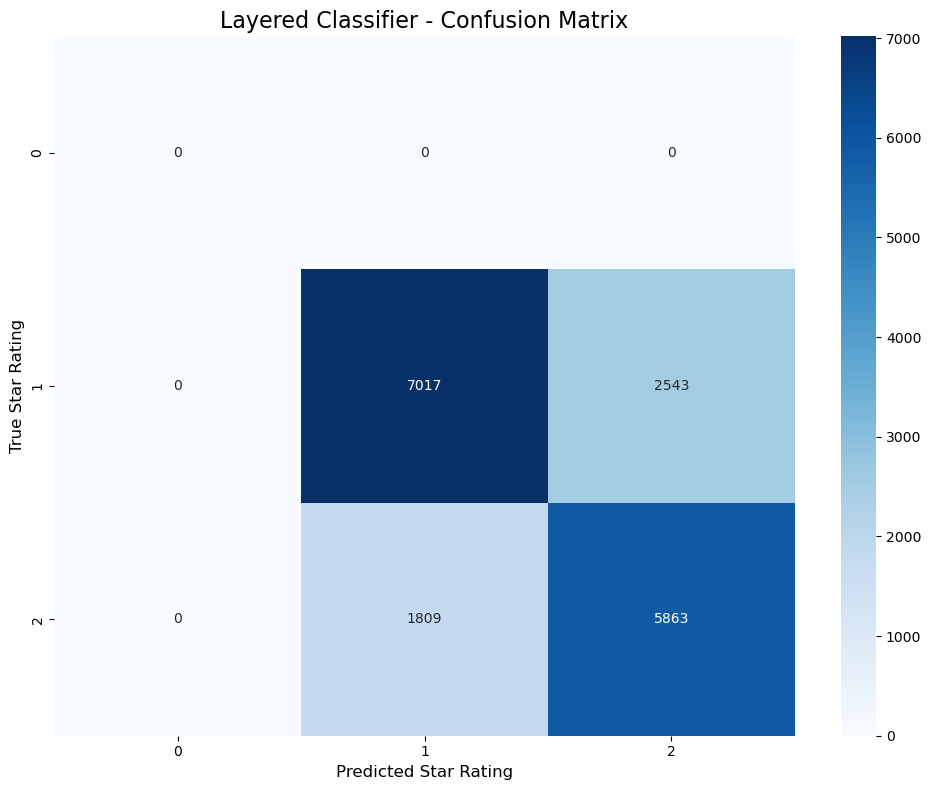

NameError: name 'baseline_report' is not defined

In [9]:
def main(data, n=500000):
    """
    Main function to train and evaluate layered classifier
    
    Args:
        data: Full dataset
        n: Sample size to use
    """
    print("="*60)
    print("LAYERED STAR RATING CLASSIFIER")
    print("="*60)
    
    # Sample data
    print(f"\nSampling {n} reviews...")
    # data_sample = data.sample(n=min(n, len(data)), random_state=42)
    # Balanced sampling
    samples_per_class = min(n // data['stars'].nunique(), data['stars'].value_counts().min())
    data_sample = (
        data.groupby('stars', group_keys=False)
            .apply(lambda x: x.sample(n=samples_per_class))
            .reset_index(drop=True)
    )
    
    print(f"\nClass distribution in sample:")
    print(data_sample['stars'].value_counts().sort_index())
    
    # Prepare features and labels
    X = data_sample['clean_text']
    y = data_sample['stars'].astype(int)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.1, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {len(X_train)} reviews")
    print(f"Test set: {len(X_test)} reviews")
    
    # Initialize and train layered classifier
    layered_clf = LayeredStarClassifier(max_features=10000, ngram_range=(1, 2))
    layered_clf.fit(X_train, y_train)
    
    # Make predictions
    print("\nMaking predictions on test set...")
    y_pred = layered_clf.predict(X_test)
    
    # Evaluate
    accuracy, macro_f1, report = evaluate_classifier(
        y_test, y_pred, 
        classifier_name="Layered Classifier"
    )
    
    # Plot confusion matrix
    plot_confusion_matrix(
        y_test, y_pred,
        title="Layered Classifier - Confusion Matrix",
        save_path="layered_classifier_confusion_matrix.png"
    )
    
    return layered_clf, report, baseline_report

# ============================================================================
# 5. RUN
# ============================================================================

if __name__ == "__main__":
    # Load data
    df = load_data()
    
    # Train and evaluate
    layered_clf, layered_report, baseline_report = main(df, n=500000)